# Klasifikasi Kesegaran Buah Menggunakan Metode GLCM dan Random Forest
## Percobaan 0 — Baseline: Grayscale Saja (Tanpa Preprocessing)
### Nama Anggota
- Thoriq Abdillah Falian Kusuma : F1D02410098
- Jasmine Aulia Santoso : F1D02410010
- Ulul Asmi : F1D002410144
- Fatriya Annastha Putra : F1D02410046

Percobaan ini berfungsi sebagai **baseline murni** — gambar hanya dikonversi ke grayscale tanpa preprocessing apapun, lalu langsung diekstrak fitur GLCM-nya. Tujuannya sebagai referensi untuk menilai apakah preprocessing pada percobaan lain benar-benar meningkatkan performa.

## Import Library

Cell dibawah mengimpor seluruh library yang dibutuhkan sepanjang program.

Library `os` digunakan untuk melakukan navigasi sistem file, sehingga program dapat membaca folder dataset dan melakukan iterasi secara otomatis pada setiap subfolder kelas. `OpenCV (cv2)` digunakan untuk membaca citra dari media penyimpanan, melakukan konversi warna dari BGR ke grayscale, serta mengubah ukuran citra (resize) agar memiliki dimensi yang seragam. Untuk keperluan visualisasi, `Matplotlib (matplotlib.pyplot)` digunakan untuk menampilkan sampel citra, grafik distribusi data, dan confusion matrix.

Dalam pengolahan data numerik, `NumPy` digunakan untuk melakukan operasi pada array multidimensi yang berfungsi menyimpan data citra, label, serta hasil perhitungan fitur. `Pandas` digunakan untuk mengelola data hasil ekstraksi fitur dalam bentuk DataFrame serta menyimpan dan membaca data dalam format CSV. Pembagian dataset menjadi data latih dan data uji dilakukan menggunakan fungsi `train_test_split` dari library `scikit-learn`, sehingga proses pembagian data dapat dilakukan secara acak namun tetap dapat direproduksi.

Pada tahap ekstraksi fitur tekstur, digunakan fungsi `graycomatrix` dan `graycoprops` dari library `scikit-image` untuk membentuk Gray-Level Co-occurrence Matrix (GLCM) dan menghitung berbagai karakteristik tekstur seperti contrast, correlation, energy, dan homogeneity. Selain itu, fungsi `entrop` dari library `SciPy` digunakan untuk menghitung nilai entropi berdasarkan distribusi probabilitas pada matriks GLCM sebagai fitur tambahan yang merepresentasikan kompleksitas tekstur citra.

Tahap klasifikasi dilakukan menggunakan tiga algoritma pembelajaran mesin dari library scikit-learn, yaitu RandomForestClassifier sebagai metode klasifikasi berbasis ensemble pohon keputusan, SVC (Support Vector Classifier) sebagai implementasi algoritma Support Vector Machine (SVM) dengan kernel Radial Basis Function (RBF), serta KNeighborsClassifier yang menerapkan metode K-Nearest Neighbors (KNN). Evaluasi performa model dilakukan menggunakan berbagai metrik dari sklearn.metrics, meliputi accuracy, precision, recall, F1-score, classification report, dan confusion matrix. Selanjutnya, Seaborn digunakan untuk menghasilkan visualisasi statistik tingkat lanjut, khususnya dalam menampilkan heatmap correlation matrix yang digunakan untuk menganalisis hubungan antar fitur yang diekstraksi.

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Data Loading

Cell ini bertugas membaca seluruh gambar dari folder `Dataset` dan melakukan resize seragam ke ukuran 250×250 piksel.

Iterasi setiap subfolder dalam direktori `Dataset/` masing-masing subfolder mewakili satu kelas label (`Fresh_Apple`, `Moderately_Fresh_Apple`, `Rotten_Apple`)
Setiap gambar dibaca menggunakan cv.imread() dalam format BGR
Gambar langsung di-resize ke 250×250 piksel menggunakan cv.resize()
Gambar, label kelas, dan nama file masing-masing disimpan ke dalam list terpisah
List dikonversi menjadi numpy array untuk efisiensi komputasi

Resize ke 250×250 dilakukan agar:

Seluruh gambar memiliki dimensi yang seragam sebagai syarat pemrosesan batch.
Ukuran data lebih ringan di memori dibanding resolusi asli.
Masih cukup besar untuk mempertahankan detail tekstur permukaan kulit apel yang dibutuhkan GLCM.
Proses ekstraksi GLCM lebih efisien karena jumlah piksel yang diproses proporsional.

In [2]:
def resize_image(image, target_size=(250, 250)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Dataset'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (250, 250))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 828
Labels: ['Fresh_Apple' 'Moderately_Fresh_Apple' 'Rotten_Apple']


## Data Understanding

## Data Understanding

Cell ini menampilkan distribusi jumlah gambar per kelas menggunakan bar chart, bertujuan untuk memahami apakah dataset seimbang atau tidak.

Karakteristik Dataset:

Fresh_Apple (Apel Segar) berjumlah 507 gambar dengan proporsi ±61.2%
Moderately_Fresh_Apple (Apel Cukup Segar) berjumlah 166 dengan proporsi ±20.0%
Rotten_Apple (Apel Busuk) berjumlah 155 gambar dengan proporsi ±18.7%
Total gambar 828  dengan proporsi 100%

Analisis Karakteristik Data:


Distribusi tidak seimbang (imbalanced): Kelas Fresh_Apple mendominasi dengan 507 gambar (~3× lebih banyak dari kelas lainnya). Ini dapat menyebabkan model cenderung bias memprediksi kelas mayoritas. Sehingga perlu diperhatikan saat interpretasi metrik evaluasi.
Kondisi gambar: Gambar diambil dengan kamera smartphone, sehingga terdapat variasi dalam pencahayaan (kondisi ruangan), background (meja, tembok, dll), dan sudut pengambilan gambar.
Noise: Gambar berpotensi mengandung noise salt-and-pepper akibat sensor kamera dan kompresi JPEG, yang menjadi alasan utama penerapan Median Filter pada tahap preprocessing.
Konten visual: Apel segar memiliki permukaan mulus dan warna merah/hijau cerata; apel cukup segar mulai menunjukkan bercak atau perubahan warna; apel busuk memiliki tekstur permukaan tidak rata dengan bercak coklat/hitam yang signifikan.


Bar chart divisualisasikan dengan warna hijau (Fresh), oranye (Moderately Fresh), dan merah (Rotten) dengan label jumlah di atas setiap bar.

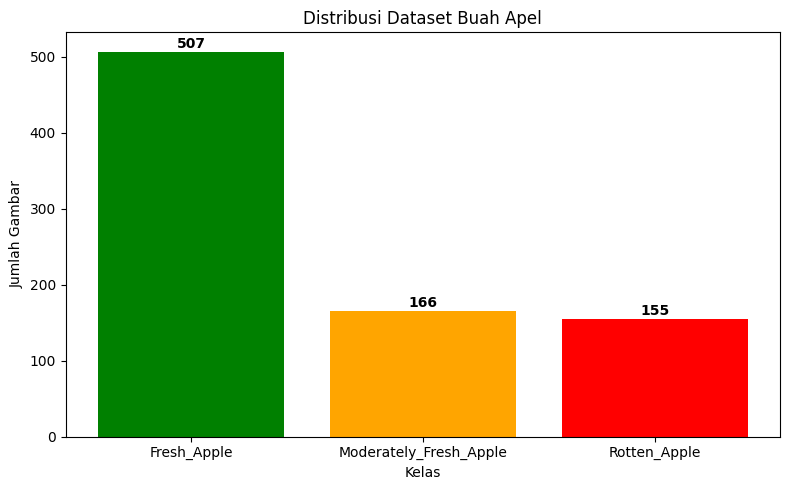

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['green', 'orange', 'red'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Buah Apel')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Sample Data

Cell ini menampilkan contoh gambar dari setiap kelas dalam format grid menggunakan fungsi `show_sample_images()`.

Fungsi `show_sample_images()` menerima array gambar, label, nama kelas, dan jumlah sampel per kelas (default n=3).
Untuk setiap kelas, diambil indeks gambar yang sesuai `(np.where(labels == cls))`.
Gambar ditampilkan dalam grid berukuran `jumlah_kelas × n (3 baris × 3 kolom = 9 gambar)`.
Gambar BGR dikonversi ke RGB (cv.COLOR_BGR2RGB) sebelum ditampilkan agar warna tampak benar di matplotlib.
Setiap gambar diberi judul nama kelasnya dan axis dinonaktifkan untuk tampilan yang bersih.


Tujuan: Memverifikasi secara visual bahwa gambar berhasil dibaca dengan benar, warna tampak natural, dan label sesuai dengan konten gambar. Ini juga membantu memahami perbedaan visual antar kelas sebelum masuk ke tahap preprocessing.

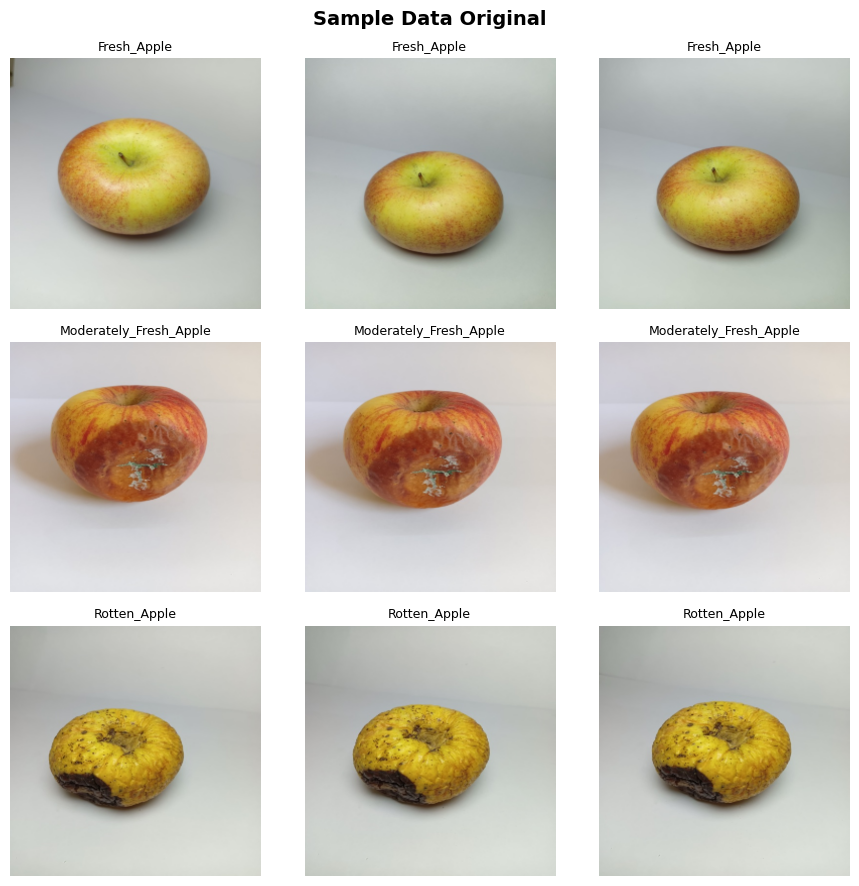

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Grayscale (Tanpa Preprocessing Tambahan)

Cell ini mengkonversi seluruh gambar dari format BGR menjadi citra grayscale menggunakan fungsi `cv.cvtColor()`.

Pada percobaan baseline ini tidak dilakukan preprocessing tambahan. Citra grayscale yang dihasilkan akan langsung digunakan untuk proses ekstraksi fitur tekstur.

Output yang dihasilkan berupa kumpulan citra satu kanal yang hanya berisi informasi intensitas keabuan. Informasi warna dihilangkan sehingga analisis difokuskan pada pola distribusi intensitas dan tekstur citra.

Karakteristik grayscale sangat dipengaruhi oleh pencahayaan, kontras alami citra, kualitas kamera, dan kondisi objek saat pengambilan gambar. Karena tidak ada preprocessing tambahan, seluruh noise dan variasi pencahayaan tetap dipertahankan sehingga hasil baseline dapat digunakan sebagai pembanding terhadap percobaan preprocessing berikutnya.

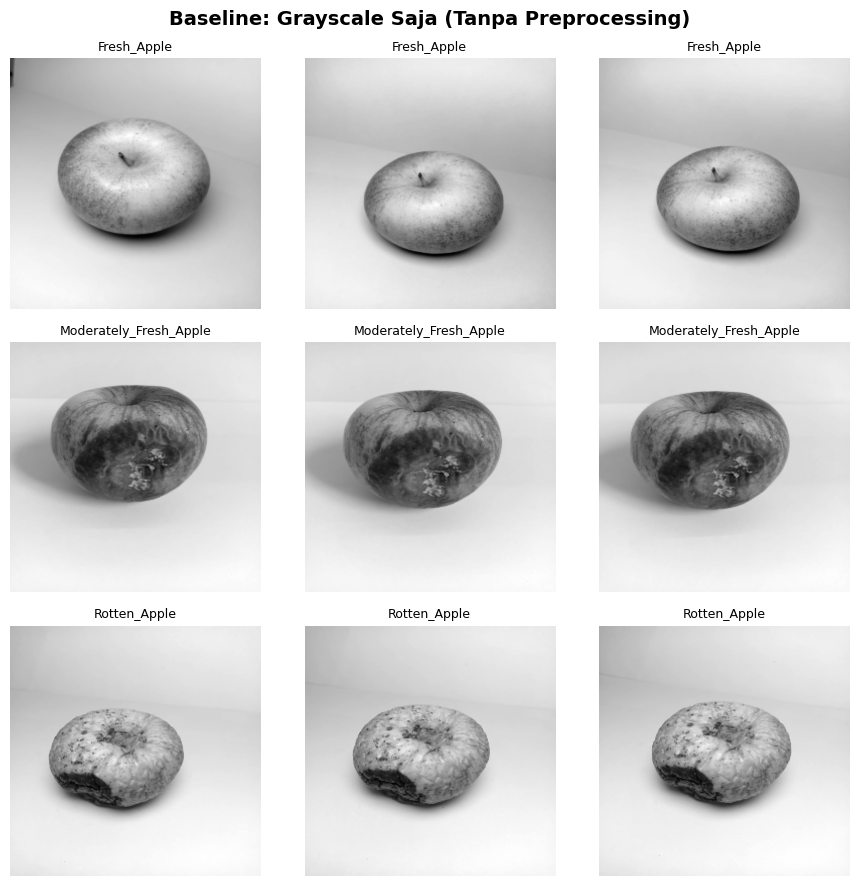

In [5]:
# Hanya konversi ke grayscale, TANPA preprocessing apapun
dataPreprocessed = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    dataPreprocessed.append(gray)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Baseline: Grayscale Saja (Tanpa Preprocessing)')

## Feature Extraction — GLCM
Mengekstrak 7 fitur tekstur dari GLCM pada 4 sudut (0°, 45°, 90°, 135°):
- Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, Correlation

Total: 7 fitur × 4 sudut = **28 fitur per gambar**

Cell ini mendefinisikan fungsi-fungsi untuk menghitung matriks GLCM dan mengekstrak 7 fitur tekstur dari 4 sudut arah.

Fungsi glcm(image, derajat):
Menghitung matriks GLCM menggunakan graycomatrix() dari scikit-image dengan parameter:

distances=[1] adalah jarak antar piksel yang diperhitungkan = 1 piksel
angles disesuaikan berdasarkan sudut input (0°, 45°, 90°, atau 135°)
levels=256 adalah jumlah level intensitas (8-bit grayscale)
symmetric=True adalah matriks simetris (pasangan (i,j) dan (j,i) keduanya dihitung)
normed=True adalah dinormalisasi menjadi distribusi probabilitas


Fitur Tekstur GLCM yang Digunakan

1. Contrast

Dihitung menggunakan fungsi graycoprops(m, 'contrast').
Mengukur tingkat perbedaan intensitas antara piksel yang bertetangga dalam citra.
Nilai contrast yang tinggi menunjukkan adanya perbedaan intensitas yang besar, sehingga tekstur cenderung kasar dan tidak seragam.
Pada kasus klasifikasi kualitas apel, apel yang mengalami pembusukan umumnya memiliki nilai contrast lebih tinggi dibandingkan apel segar karena permukaannya lebih tidak merata.

2. Dissimilarity

Dihitung menggunakan fungsi graycoprops(m, 'dissimilarity').
Mengukur variasi lokal tekstur berdasarkan perbedaan tingkat keabuan antar piksel yang berdekatan.
Mirip dengan contrast, tetapi peningkatan nilainya bersifat linear terhadap perbedaan intensitas.
Semakin tinggi nilai dissimilarity, semakin besar variasi tekstur yang terdapat pada citra.

3. Homogeneity

Dihitung menggunakan fungsi graycoprops(m, 'homogeneity').
Mengukur kedekatan distribusi nilai pada matriks GLCM terhadap diagonal utama.
Nilai homogeneity yang tinggi menunjukkan bahwa sebagian besar pasangan piksel memiliki tingkat keabuan yang mirip.
Tekstur yang halus dan seragam, seperti pada apel segar, umumnya menghasilkan nilai homogeneity yang tinggi.

4. Angular Second Moment (ASM)

Dihitung menggunakan fungsi graycoprops(m, 'ASM').
Mengukur tingkat keseragaman atau keteraturan pola tekstur dalam citra.
Nilai ASM yang tinggi menunjukkan bahwa distribusi pasangan piksel terkonsentrasi pada beberapa nilai tertentu.
Semakin teratur tekstur suatu citra, semakin tinggi nilai ASM yang dihasilkan.

5. Energy

Dihitung menggunakan fungsi graycoprops(m, 'energy').
Merupakan akar kuadrat dari nilai ASM.
Menggambarkan tingkat keseragaman tekstur pada citra.
Nilai energy yang tinggi menunjukkan tekstur yang lebih halus, teratur, dan homogen.

6. Correlation

Dihitung menggunakan fungsi graycoprops(m, 'correlation').
Mengukur tingkat hubungan atau ketergantungan linear antara intensitas piksel yang bertetangga.
Nilai correlation yang tinggi menunjukkan adanya pola hubungan yang kuat antara pasangan piksel dalam arah tertentu.
Fitur ini membantu mengidentifikasi struktur atau pola tekstur yang konsisten pada citra.

7. Entropy

Dihitung menggunakan fungsi entropy(matriks.ravel()).
Mengukur tingkat ketidakteraturan, kompleksitas, atau keacakan distribusi tekstur dalam citra.
Nilai entropy yang tinggi menunjukkan tekstur yang lebih kompleks dan tidak teratur.
Sebaliknya, nilai entropy yang rendah menunjukkan tekstur yang lebih sederhana dan seragam.

Total fitur: 7 fitur × 4 sudut (0°, 45°, 90°, 135°) = 28 fitur per gambar

Pendekatan multi-sudut ini memastikan fitur tekstur bersifat isotropik mampu menangkap pola tekstur dari semua arah, sehingga lebih robust terhadap orientasi gambar.

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

### Hitung GLCM untuk setiap gambar pada 4 sudut

Cell ini mengekstrak nilai numerik dari setiap matriks GLCM yang sudah dihitung sebelumnya.

Inisialisasi 28 list kosong (7 fitur × 4 sudut): Kontras0, Kontras45, ..., correlation135
Loop 828 iterasi: untuk setiap gambar, memanggil 7 fungsi fitur pada matriks GLCM dari 4 sudut
Total pemanggilan fungsi: 828 × 7 × 4 = 23.184 perhitungan fitur
Setiap hasil (nilai skalar float) diappend ke list yang sesuai

Fungsi cell ini:
Mengubah representasi matriks GLCM (yang tidak bisa langsung digunakan oleh algoritma ML) menjadi vektor fitur numerik untuk setiap gambar. Setelah cell ini selesai, setiap gambar direpresentasikan oleh 28 angka yang menggambarkan karakteristik teksturnya dari berbagai sudut.

In [7]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 828 images


### Ekstraksi 7 Fitur dari GLCM

Cell ini mengekstrak nilai numerik dari setiap matriks GLCM yang sudah dihitung sebelumnya.

Inisialisasi 28 list kosong (7 fitur × 4 sudut): Kontras0, Kontras45, ..., correlation135
Loop 828 iterasi: untuk setiap gambar, memanggil 7 fungsi fitur pada matriks GLCM dari 4 sudut
Total pemanggilan fungsi: 828 × 7 × 4 = 23.184 perhitungan fitur
Setiap hasil (nilai skalar float) diappend ke list yang sesuai

Fungsi cell ini:
Mengubah representasi matriks GLCM (yang tidak bisa langsung digunakan oleh algoritma ML) menjadi vektor fitur numerik untuk setiap gambar. Setelah cell ini selesai, setiap gambar direpresentasikan oleh 28 angka yang menggambarkan karakteristik teksturnya dari berbagai sudut.

In [8]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


### Simpan Hasil Ekstraksi ke CSV

Cell ini menggabungkan seluruh fitur tekstur hasil ekstraksi GLCM ke dalam sebuah DataFrame kemudian menyimpannya dalam format CSV. Setiap baris pada dataset merepresentasikan satu citra, sedangkan setiap kolom merepresentasikan fitur tekstur yang dihitung dari matriks GLCM pada empat arah pengamatan yang berbeda.

Output yang dihasilkan berupa file `hasil_ekstraksi_baseline.csv` yang berisi 828 data citra dengan total 30 kolom. Dua kolom pertama terdiri dari `Filename` dan `Label`, sedangkan 28 kolom sisanya merupakan fitur tekstur GLCM yang berasal dari tujuh fitur statistik yaitu Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, dan Correlation pada sudut 0°, 45°, 90°, dan 135°.

Hasil ini menunjukkan bahwa seluruh citra berhasil direpresentasikan ke dalam bentuk numerik tanpa kehilangan identitas data asli karena nama file dan label kelas tetap disimpan. Representasi numerik tersebut sangat penting karena algoritma machine learning tidak dapat memproses citra secara langsung, melainkan membutuhkan data dalam bentuk angka yang menggambarkan karakteristik visual objek.

Jumlah fitur yang dihasilkan dipengaruhi oleh banyaknya parameter tekstur yang digunakan dan jumlah sudut pengamatan pada proses GLCM. Penggunaan empat sudut berbeda bertujuan untuk menangkap pola tekstur dari berbagai orientasi sehingga informasi yang diperoleh menjadi lebih lengkap. Sebagai contoh, tekstur yang tampak dominan pada arah horizontal mungkin menghasilkan nilai yang berbeda ketika diamati pada arah vertikal atau diagonal.

Berdasarkan hasil ekstraksi, terlihat bahwa nilai Correlation pada sebagian besar citra cenderung tinggi, mendekati angka 1. Kondisi ini menunjukkan bahwa piksel-piksel yang berdekatan masih memiliki hubungan intensitas yang kuat. Hal tersebut wajar karena citra pada percobaan baseline hanya melalui proses konversi grayscale tanpa preprocessing tambahan sehingga struktur tekstur asli masih dipertahankan. Sementara itu, nilai fitur lain seperti Contrast dan Dissimilarity bervariasi antar citra karena dipengaruhi oleh tingkat perbedaan intensitas dan kompleksitas tekstur pada permukaan buah.

Dataset hasil ekstraksi ini akan digunakan sebagai masukan pada tahap seleksi fitur dan klasifikasi. Kualitas fitur yang tersimpan dalam file CSV akan sangat menentukan kemampuan model dalam membedakan kelas kesegaran buah. Oleh karena itu, file hasil ekstraksi ini menjadi fondasi utama yang menghubungkan proses pengolahan citra dengan proses machine learning pada penelitian ini.

In [9]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_baseline.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_baseline.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG20260204225626.jpg,Fresh_Apple,12.350361,23.013516,16.496064,22.519250,0.671324,0.602681,0.624138,0.585969,...,0.004045,0.003448,0.070952,0.062544,0.063603,0.058720,0.992835,0.986666,0.990447,0.986952
1,IMG20260204225637.jpg,Fresh_Apple,11.577896,23.405574,16.842972,22.738424,0.669965,0.591536,0.619772,0.589961,...,0.004703,0.004207,0.075031,0.065445,0.068581,0.064863,0.991923,0.983697,0.988241,0.984162
2,IMG20260204225638.jpg,Fresh_Apple,13.680337,25.888437,19.050169,24.870889,0.705780,0.626083,0.647026,0.617632,...,0.005410,0.004802,0.082829,0.071194,0.073549,0.069300,0.990754,0.982533,0.987115,0.983219
3,IMG20260204225640.jpg,Fresh_Apple,15.358892,28.495815,21.008916,27.297334,0.684684,0.617278,0.637633,0.601731,...,0.005507,0.004778,0.081896,0.072117,0.074208,0.069123,0.990194,0.981839,0.986580,0.982603
4,IMG20260204225642.jpg,Fresh_Apple,12.333622,26.297769,18.498779,24.598603,0.687657,0.618358,0.637741,0.599855,...,0.005187,0.004520,0.080217,0.070516,0.072020,0.067232,0.992480,0.983980,0.988747,0.985015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,IMG20260409232001.jpg,Rotten_Apple,32.082394,61.189561,40.761928,51.865212,0.737863,0.656162,0.683899,0.660548,...,0.005375,0.004927,0.082688,0.069756,0.073313,0.070193,0.984158,0.969834,0.979853,0.974431
824,IMG20260409232002.jpg,Rotten_Apple,36.559711,68.716424,45.987711,57.834406,0.722294,0.641548,0.671716,0.651238,...,0.005401,0.004994,0.082217,0.069416,0.073490,0.070669,0.981355,0.965009,0.976519,0.970550
825,IMG20260409232003.jpg,Rotten_Apple,33.557221,63.477218,43.058940,54.258851,0.733186,0.651372,0.680265,0.659694,...,0.005551,0.005142,0.083727,0.070584,0.074506,0.071707,0.982870,0.967646,0.977992,0.972344
826,IMG20260409232005.jpg,Rotten_Apple,39.830458,73.285012,49.839550,62.997839,0.725625,0.648332,0.674958,0.653083,...,0.006357,0.005822,0.089189,0.075797,0.079729,0.076302,0.981811,0.966609,0.977221,0.971296


## Feature Selection

Cell ini melakukan proses seleksi fitur menggunakan Correlation Matrix untuk mengidentifikasi hubungan antar fitur hasil ekstraksi GLCM. Tujuan utama tahap ini adalah mengurangi redundansi informasi dengan menghapus fitur-fitur yang memiliki tingkat korelasi sangat tinggi sehingga model tidak mempelajari informasi yang sama secara berulang.

Output yang dihasilkan berupa heatmap korelasi yang memperlihatkan hubungan antar fitur GLCM. Nilai korelasi berada pada rentang -1 hingga 1. Nilai yang mendekati 1 menunjukkan hubungan positif yang sangat kuat, nilai yang mendekati -1 menunjukkan hubungan negatif yang sangat kuat, sedangkan nilai yang mendekati 0 menunjukkan hubungan yang lemah atau tidak memiliki hubungan linear yang signifikan.

Berdasarkan hasil correlation matrix, terlihat bahwa fitur Contrast dan Dissimilarity memiliki korelasi positif yang sangat tinggi sebesar 0.86. Kondisi ini menunjukkan bahwa kedua fitur tersebut membawa informasi yang sangat mirip. Hal ini terjadi karena keduanya sama-sama mengukur tingkat perbedaan intensitas antar piksel yang bertetangga. Ketika tekstur citra semakin kasar dan variasi intensitas semakin besar, nilai Contrast dan Dissimilarity akan meningkat secara bersamaan. Oleh karena itu, salah satu dari kedua fitur tersebut berpotensi dihapus pada tahap seleksi fitur karena memberikan informasi yang relatif redundan.

Hubungan kuat lainnya terlihat antara Entropy dan Dissimilarity dengan nilai korelasi sebesar 0.64. Korelasi ini menunjukkan bahwa citra yang memiliki variasi intensitas tinggi cenderung memiliki tingkat ketidakteraturan yang tinggi pula. Secara teoritis hal ini dapat dijelaskan karena Entropy mengukur kompleksitas distribusi probabilitas pada GLCM, sedangkan Dissimilarity mengukur besarnya perbedaan intensitas antar piksel. Ketika tekstur semakin kompleks, kedua fitur tersebut akan meningkat secara bersamaan.

Pada sisi lain, terdapat korelasi negatif yang sangat kuat antara Entropy dan ASM dengan nilai sebesar -0.80. Hasil ini merupakan kondisi yang sangat umum pada fitur GLCM. Entropy menggambarkan tingkat ketidakteraturan tekstur, sedangkan ASM (Angular Second Moment) mengukur tingkat keseragaman distribusi tekstur. Ketika suatu citra memiliki pola tekstur yang kompleks dan tidak teratur, nilai Entropy akan meningkat, sementara nilai ASM akan menurun karena distribusi probabilitas menjadi lebih menyebar. Sebaliknya, apabila tekstur sangat seragam, nilai ASM akan meningkat dan Entropy akan menurun. Hubungan berlawanan inilah yang menghasilkan korelasi negatif yang sangat tinggi.

Korelasi negatif kuat juga terlihat antara Homogeneity dan Entropy dengan nilai sebesar -0.71. Hal ini menunjukkan bahwa semakin seragam suatu tekstur, semakin rendah tingkat kompleksitasnya. Fitur Homogeneity akan menghasilkan nilai tinggi ketika sebagian besar pasangan piksel memiliki intensitas yang mirip, sedangkan Entropy akan tinggi ketika distribusi pasangan piksel menjadi lebih acak. Oleh karena itu kedua fitur secara alami bergerak ke arah yang berlawanan.

Hubungan negatif lainnya muncul antara Contrast dan Correlation dengan nilai sebesar -0.70. Kondisi ini menunjukkan bahwa ketika variasi intensitas antar piksel meningkat, hubungan linear antar piksel cenderung menurun. Pada tekstur yang kasar dan tidak beraturan, nilai Contrast biasanya tinggi karena banyak terjadi perubahan intensitas, sedangkan Correlation menurun karena hubungan antar piksel menjadi lebih lemah.

Fitur ASM dan Homogeneity menunjukkan korelasi positif sebesar 0.32. Nilai ini relatif sedang dan masih dapat diterima karena kedua fitur memang sama-sama berkaitan dengan tingkat keteraturan tekstur. Namun korelasi tersebut tidak cukup tinggi untuk dianggap redundan sehingga keduanya masih berpotensi memberikan informasi yang berbeda bagi model klasifikasi.

Secara keseluruhan, pola korelasi yang muncul menunjukkan bahwa sebagian besar fitur GLCM memang saling berhubungan karena dihitung dari matriks probabilitas yang sama. Meskipun demikian, tidak semua fitur memberikan informasi yang identik. Beberapa fitur mengukur aspek yang berbeda dari tekstur, seperti tingkat variasi intensitas, keseragaman, kompleksitas, maupun hubungan spasial antar piksel. Oleh karena itu, proses feature selection menjadi penting untuk mempertahankan fitur-fitur yang paling representatif sekaligus mengurangi fitur yang memiliki informasi berulang.

Hasil correlation matrix pada percobaan baseline juga menunjukkan bahwa meskipun citra hanya menggunakan grayscale tanpa preprocessing tambahan, hubungan antar fitur masih mampu menggambarkan karakteristik tekstur objek dengan baik. Variasi nilai korelasi yang muncul dipengaruhi oleh kondisi alami citra seperti pencahayaan, kualitas kamera, tingkat kematangan buah, pola permukaan kulit buah, keberadaan noise, serta distribusi intensitas piksel pada setiap gambar. Faktor-faktor tersebut menyebabkan setiap fitur merespons tekstur dengan cara yang berbeda sehingga menghasilkan pola korelasi yang beragam.

Melalui proses seleksi fitur berdasarkan korelasi ini, diharapkan model klasifikasi dapat bekerja lebih efisien, mengurangi risiko overfitting, mempercepat waktu pelatihan, dan meningkatkan kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 6
Fitur terpilih: ['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Correlation0']


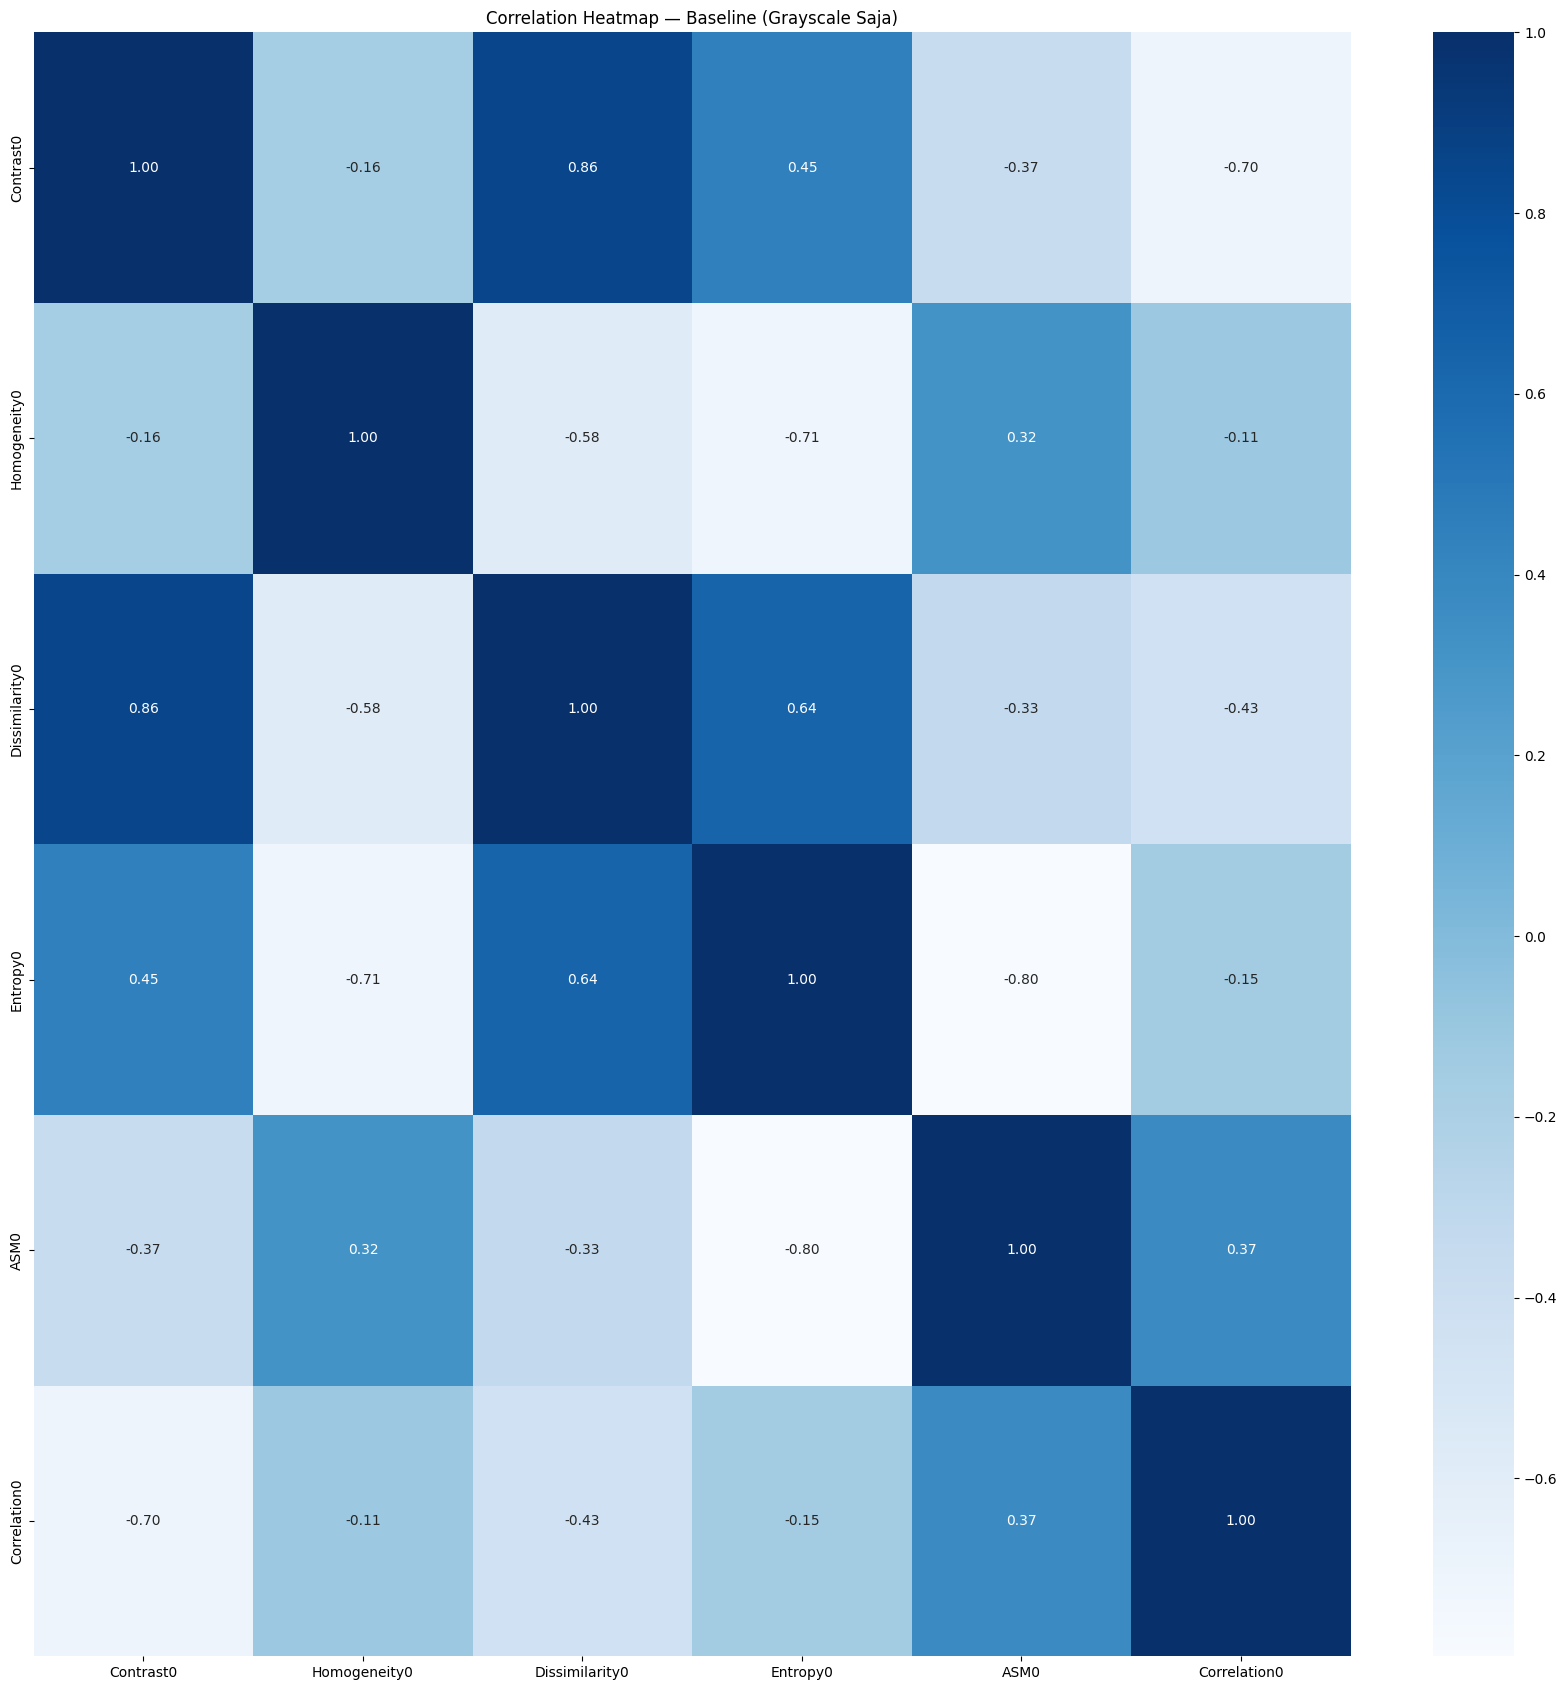

In [10]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Baseline (Grayscale Saja)')
plt.tight_layout()
plt.show()

## Splitting Data

Cell ini membagi dataset hasil feature selection menjadi data training dan data testing menggunakan fungsi `train_test_split()`. Tujuannya adalah agar model dapat dilatih menggunakan sebagian data dan dievaluasi menggunakan data yang belum pernah dilihat sebelumnya.

Output menunjukkan bahwa dataset dibagi menjadi 662 data training dan 166 data testing dengan masing-masing data memiliki 6 fitur terpilih. Jumlah fitur tersebut merupakan hasil proses feature selection yang sebelumnya mengurangi 28 fitur GLCM menjadi hanya fitur-fitur yang paling relevan.

Proporsi pembagian sekitar 80% untuk training dan 20% untuk testing dipilih karena mampu memberikan keseimbangan antara proses pembelajaran dan evaluasi model. Jumlah data training yang lebih besar membantu model mempelajari pola tekstur secara lebih baik, sedangkan data testing digunakan untuk mengukur kemampuan generalisasi model terhadap data baru.

Pengurangan jumlah fitur dari 28 menjadi 6 juga membantu mengurangi kompleksitas model, mempercepat proses pelatihan, serta menurunkan risiko overfitting karena model hanya menggunakan fitur yang dianggap paling informatif untuk proses klasifikasi.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (662, 6)
Testing set: (166, 6)


## Feature Normalization

Cell ini melakukan normalisasi fitur menggunakan metode standardisasi atau Z-Score Normalization.

Normalisasi dilakukan agar seluruh fitur berada pada skala yang relatif sama sehingga tidak ada fitur tertentu yang mendominasi proses pembelajaran model.

Output yang dihasilkan berupa dataset baru dengan distribusi nilai yang telah dinormalisasi. Tahap ini sangat penting terutama untuk algoritma yang sensitif terhadap skala data seperti Support Vector Machine dan K-Nearest Neighbor.

In [12]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling

Cell ini mendefinisikan fungsi evaluasi serta menginisialisasi model klasifikasi yang akan digunakan pada percobaan baseline.

Fungsi evaluasi digunakan untuk menghitung berbagai metrik performa seperti Accuracy, Precision, Recall, dan F1-Score. Metrik tersebut akan digunakan untuk menilai kemampuan model dalam mengenali tingkat kesegaran buah berdasarkan fitur tekstur yang telah diekstraksi.

In [13]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

Cell ini melatih model Random Forest menggunakan data training yang telah melalui proses feature selection dan normalisasi, kemudian mengevaluasi performanya pada data training dan data testing menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

Hasil evaluasi menunjukkan bahwa model memperoleh akurasi sebesar 100% pada data training. Seluruh kelas, yaitu Fresh Apple, Moderately Fresh Apple, dan Rotten Apple, memiliki nilai Precision, Recall, dan F1-Score sebesar 1.00. Hasil ini menunjukkan bahwa model mampu mempelajari pola pada data training dengan sangat baik tanpa menghasilkan kesalahan klasifikasi.

Pada data testing, model memperoleh akurasi sebesar 90.96%. Kelas Fresh Apple memiliki performa yang baik dengan F1-Score sebesar 0.93, sedangkan kelas Rotten Apple berhasil diklasifikasikan secara sempurna dengan Precision, Recall, dan F1-Score sebesar 1.00. Sementara itu, kelas Moderately Fresh Apple memiliki performa terendah dengan Recall sebesar 0.67 dan F1-Score sebesar 0.75, yang menunjukkan bahwa sebagian sampel pada kelas ini masih sering salah diklasifikasikan ke kelas lain.

Perbedaan antara akurasi training yang mencapai 100% dan akurasi testing sebesar 90.96% mengindikasikan adanya kecenderungan overfitting ringan, yaitu model sangat baik dalam mengenali data yang pernah dipelajari tetapi mengalami sedikit penurunan performa pada data baru. Namun demikian, selisih performa tersebut masih tergolong wajar mengingat Random Forest memang memiliki kemampuan yang sangat baik dalam mempelajari pola data.

Hasil ini menunjukkan bahwa enam fitur hasil feature selection masih mampu merepresentasikan karakteristik tekstur citra dengan baik meskipun hanya menggunakan citra grayscale tanpa preprocessing tambahan. Tingginya akurasi testing juga menunjukkan bahwa informasi tekstur yang terkandung dalam citra asli sudah cukup kuat untuk membedakan tingkat kesegaran apel. Kesalahan klasifikasi yang masih terjadi pada kelas Moderately Fresh Apple kemungkinan disebabkan oleh karakteristik teksturnya yang berada di antara kelas Fresh Apple dan Rotten Apple sehingga memiliki kemiripan dengan kedua kelas tersebut.

In [14]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       1.00      1.00      1.00       409
Moderately_Fresh_Apple       1.00      1.00      1.00       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           1.00       662
             macro avg       1.00      1.00      1.00       662
          weighted avg       1.00      1.00      1.00       662

Accuracy: 1.0

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.90      0.96      0.93        98
Moderately_Fresh_Apple       0.85      0.67      0.75        33
          Rotten_Apple       1.00      1.00      1.00        35

              accuracy                           0.91       166
             macro avg       0.91      0.88      0.89       166
          weighted avg       0.91      0.91      0.91       166

Accuracy: 0.9096385542168675


### Train SVM Classifier

Cell ini melatih model Support Vector Machine (SVM) menggunakan data training yang telah melalui proses feature selection dan normalisasi, kemudian mengevaluasi performanya pada data training dan data testing menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

Hasil evaluasi pada data training menunjukkan akurasi sebesar 88.22%. Kelas Rotten Apple memiliki performa terbaik dengan nilai Precision, Recall, dan F1-Score sebesar 1.00, yang menunjukkan bahwa karakteristik tekstur kelas ini dapat dipisahkan dengan sangat jelas oleh model. Sementara itu, kelas Fresh Apple memiliki F1-Score sebesar 0.91 dan kelas Moderately Fresh Apple memiliki F1-Score sebesar 0.66. Nilai Recall yang lebih rendah pada kelas Moderately Fresh Apple menunjukkan bahwa sebagian data pada kelas tersebut masih sering diklasifikasikan ke kelas lain.

Pada data testing, model memperoleh akurasi sebesar 86.14%. Kelas Fresh Apple tetap menunjukkan performa yang baik dengan F1-Score sebesar 0.89, sedangkan kelas Rotten Apple kembali berhasil diklasifikasikan secara sempurna dengan nilai Precision, Recall, dan F1-Score sebesar 1.00. Kelas Moderately Fresh Apple masih menjadi kelas yang paling sulit dikenali dengan Recall sebesar 0.52 dan F1-Score sebesar 0.60, yang menunjukkan bahwa hampir setengah data pada kelas ini masih mengalami kesalahan klasifikasi.

Perbedaan akurasi antara data training sebesar 88.22% dan data testing sebesar 86.14% relatif kecil. Hal ini menunjukkan bahwa model memiliki kemampuan generalisasi yang cukup baik dan tidak mengalami overfitting yang signifikan. Model mampu mempertahankan performa yang relatif konsisten ketika dihadapkan pada data baru yang tidak digunakan selama proses pelatihan.

Hasil ini menunjukkan bahwa enam fitur hasil feature selection mampu memberikan informasi yang cukup baik bagi algoritma SVM untuk membedakan tingkat kesegaran apel. Namun, dibandingkan dengan Random Forest, performa SVM masih lebih rendah. Salah satu penyebabnya adalah karena batas pemisah antar kelas pada ruang fitur kemungkinan tidak sepenuhnya dapat direpresentasikan oleh hyperplane yang dibentuk oleh SVM. Selain itu, kelas Moderately Fresh Apple memiliki karakteristik tekstur yang berada di antara kelas Fresh Apple dan Rotten Apple sehingga menghasilkan area tumpang tindih yang lebih besar pada ruang fitur.

Secara keseluruhan, hasil ini menunjukkan bahwa metode baseline berbasis citra grayscale dan fitur GLCM sudah mampu menghasilkan performa klasifikasi yang cukup baik dengan akurasi testing di atas 85%. Meskipun demikian, masih terdapat peluang peningkatan performa melalui penerapan preprocessing citra pada percobaan berikutnya untuk memperjelas karakteristik tekstur dan meningkatkan pemisahan antar kelas, terutama pada kelas Moderately Fresh Apple.

In [15]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.87      0.95      0.91       409
Moderately_Fresh_Apple       0.79      0.56      0.66       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           0.88       662
             macro avg       0.89      0.84      0.86       662
          weighted avg       0.88      0.88      0.87       662

Accuracy: 0.8821752265861027

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.85      0.93      0.89        98
Moderately_Fresh_Apple       0.71      0.52      0.60        33
          Rotten_Apple       1.00      1.00      1.00        35

              accuracy                           0.86       166
             macro avg       0.85      0.81      0.83       166
          weighted avg       0.85      0.86      0.85       166

Accuracy: 0.8614457

### Train KNN Classifier

### Train K-Nearest Neighbor (KNN) Classifier

Cell ini melatih model K-Nearest Neighbor (KNN) menggunakan data training yang telah melalui proses feature selection dan normalisasi. KNN bekerja dengan menghitung jarak antara data uji dan sejumlah tetangga terdekat pada data training, kemudian menentukan kelas berdasarkan mayoritas tetangga yang ditemukan.

Hasil evaluasi pada data training menunjukkan akurasi sebesar 93.05%. Kelas Fresh Apple memiliki F1-Score sebesar 0.94, kelas Moderately Fresh Apple memiliki F1-Score sebesar 0.82, sedangkan kelas Rotten Apple berhasil diklasifikasikan secara sempurna dengan Precision, Recall, dan F1-Score sebesar 1.00. Hasil ini menunjukkan bahwa model mampu mempelajari pola tekstur dari data training dengan cukup baik menggunakan enam fitur hasil feature selection.

Pada data testing, model memperoleh akurasi sebesar 84.94%. Kelas Rotten Apple kembali menunjukkan performa terbaik dengan nilai Precision, Recall, dan F1-Score sebesar 1.00. Hal ini menunjukkan bahwa karakteristik tekstur apel busuk memiliki perbedaan yang cukup jelas dibandingkan kelas lainnya sehingga mudah dikenali oleh model. Kelas Fresh Apple juga menunjukkan performa yang baik dengan F1-Score sebesar 0.87. Sementara itu, kelas Moderately Fresh Apple memiliki F1-Score sebesar 0.65 dengan Recall sebesar 0.70, yang menunjukkan bahwa sebagian data pada kelas ini masih sering tertukar dengan kelas lain.

Perbedaan antara akurasi training sebesar 93.05% dan akurasi testing sebesar 84.94% menunjukkan adanya penurunan performa ketika model dihadapkan pada data baru. Meskipun penurunan tersebut tidak terlalu ekstrem, kondisi ini mengindikasikan bahwa model KNN lebih sensitif terhadap variasi data dibandingkan Random Forest. Hal ini terjadi karena KNN melakukan klasifikasi berdasarkan kedekatan jarak antar sampel sehingga performanya sangat bergantung pada distribusi data pada ruang fitur.

Kinerja yang lebih rendah pada kelas Moderately Fresh Apple menunjukkan bahwa kelas ini memiliki karakteristik tekstur yang berada di antara Fresh Apple dan Rotten Apple. Sebagai kelas transisi, pola teksturnya sering kali memiliki kemiripan dengan kedua kelas lainnya sehingga jarak antar sampel menjadi lebih sulit dibedakan oleh algoritma KNN. Kondisi ini menyebabkan sebagian data Moderately Fresh Apple diprediksi sebagai Fresh Apple atau Rotten Apple.

Secara keseluruhan, hasil KNN menunjukkan bahwa enam fitur GLCM hasil feature selection sudah mampu memberikan informasi tekstur yang cukup baik untuk proses klasifikasi. Namun, dibandingkan dengan Random Forest yang memperoleh akurasi testing sebesar 90.96% dan SVM sebesar 86.14%, performa KNN masih sedikit lebih rendah dengan akurasi testing sebesar 84.94%. Hal ini menunjukkan bahwa pada percobaan baseline, pola hubungan antar fitur tekstur lebih efektif dipelajari oleh Random Forest dibandingkan pendekatan berbasis jarak yang digunakan oleh KNN.

In [16]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.94      0.95      0.94       409
Moderately_Fresh_Apple       0.85      0.80      0.82       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           0.93       662
             macro avg       0.93      0.92      0.92       662
          weighted avg       0.93      0.93      0.93       662

Accuracy: 0.9305135951661632

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.89      0.85      0.87        98
Moderately_Fresh_Apple       0.61      0.70      0.65        33
          Rotten_Apple       1.00      1.00      1.00        35

              accuracy                           0.85       166
             macro avg       0.83      0.85      0.84       166
          weighted avg       0.86      0.85      0.85       166

Accuracy: 0.8493975

## Evaluation — Confusion Matrix

## Evaluation - Confusion Matrix

Cell ini menampilkan confusion matrix dari model Random Forest, SVM, dan KNN untuk menganalisis hasil klasifikasi secara lebih rinci. Confusion matrix digunakan untuk membandingkan label aktual dengan label hasil prediksi sehingga dapat diketahui jumlah data yang berhasil maupun gagal diklasifikasikan pada setiap kelas.

Pada model Random Forest, sebanyak 94 dari 98 data Fresh Apple berhasil diklasifikasikan dengan benar, sedangkan 4 data lainnya salah diklasifikasikan sebagai Moderately Fresh Apple. Untuk kelas Moderately Fresh Apple, sebanyak 22 dari 33 data berhasil dikenali dengan benar, sementara 11 data salah diprediksi sebagai Fresh Apple. Seluruh 35 data Rotten Apple berhasil diklasifikasikan dengan benar tanpa kesalahan. Hasil ini menunjukkan bahwa Random Forest memiliki kemampuan yang sangat baik dalam membedakan tekstur apel busuk dan menghasilkan performa terbaik dibandingkan model lainnya.

Pada model SVM, sebanyak 91 data Fresh Apple berhasil diklasifikasikan dengan benar dan 7 data salah diprediksi sebagai Moderately Fresh Apple. Untuk kelas Moderately Fresh Apple, hanya 17 data yang berhasil dikenali dengan benar, sedangkan 16 data lainnya salah diprediksi sebagai Fresh Apple. Sama seperti Random Forest, seluruh data Rotten Apple berhasil dikenali dengan benar. Jumlah kesalahan yang lebih besar pada kelas Moderately Fresh Apple menunjukkan bahwa batas pemisah yang dibentuk oleh SVM masih belum mampu memisahkan kelas transisi tersebut secara optimal.

Pada model KNN, sebanyak 83 data Fresh Apple berhasil diklasifikasikan dengan benar dan 15 data lainnya salah diprediksi sebagai Moderately Fresh Apple. Untuk kelas Moderately Fresh Apple, sebanyak 23 data berhasil dikenali dengan benar dan 10 data salah diprediksi sebagai Fresh Apple. Seluruh data Rotten Apple kembali berhasil diklasifikasikan dengan benar. Meskipun KNN mampu mengenali kelas Moderately Fresh Apple sedikit lebih baik dibandingkan SVM, model ini menghasilkan kesalahan yang lebih banyak pada kelas Fresh Apple sehingga akurasi keseluruhan menjadi lebih rendah.

Berdasarkan ketiga confusion matrix tersebut, terlihat bahwa hampir seluruh kesalahan klasifikasi terjadi antara kelas Fresh Apple dan Moderately Fresh Apple. Tidak ditemukan kesalahan klasifikasi yang melibatkan kelas Rotten Apple, yang menunjukkan bahwa karakteristik tekstur apel busuk memiliki perbedaan yang cukup jelas dibandingkan dua kelas lainnya. Sebaliknya, kelas Moderately Fresh Apple merupakan kelas yang paling sulit dikenali karena berada pada kondisi transisi antara apel segar dan apel busuk sehingga memiliki karakteristik tekstur yang cenderung tumpang tindih dengan kelas Fresh Apple.

Pola kesalahan ini menunjukkan bahwa fitur GLCM yang diekstraksi dari citra grayscale sudah sangat baik dalam membedakan apel busuk, namun masih mengalami kesulitan ketika harus membedakan tingkat kesegaran yang berdekatan. Faktor-faktor seperti kemiripan tekstur permukaan, variasi pencahayaan saat pengambilan citra, distribusi intensitas piksel, serta tidak adanya preprocessing tambahan pada percobaan baseline dapat memengaruhi kemampuan model dalam memisahkan kelas Fresh Apple dan Moderately Fresh Apple secara lebih akurat.

Secara keseluruhan, hasil confusion matrix mendukung hasil evaluasi sebelumnya yang menunjukkan bahwa Random Forest merupakan model terbaik pada percobaan baseline dengan akurasi testing sebesar 90.96%, diikuti oleh SVM sebesar 86.14% dan KNN sebesar 84.94%. Dominasi nilai pada diagonal utama menunjukkan bahwa fitur tekstur GLCM dari citra grayscale sudah mampu merepresentasikan karakteristik kesegaran buah dengan cukup baik, meskipun masih terdapat peluang peningkatan performa melalui penerapan preprocessing pada percobaan berikutnya.

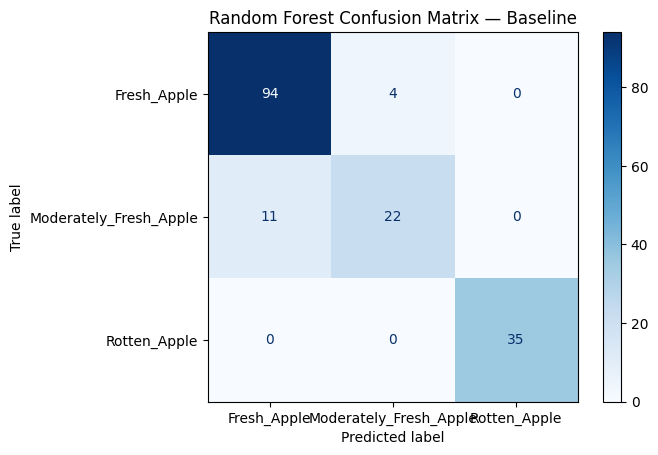

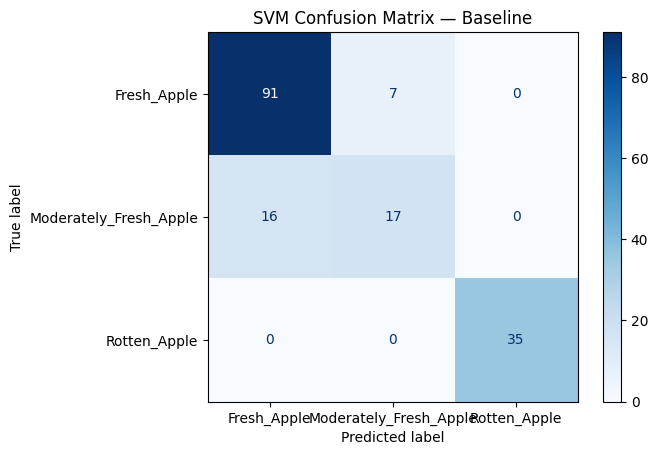

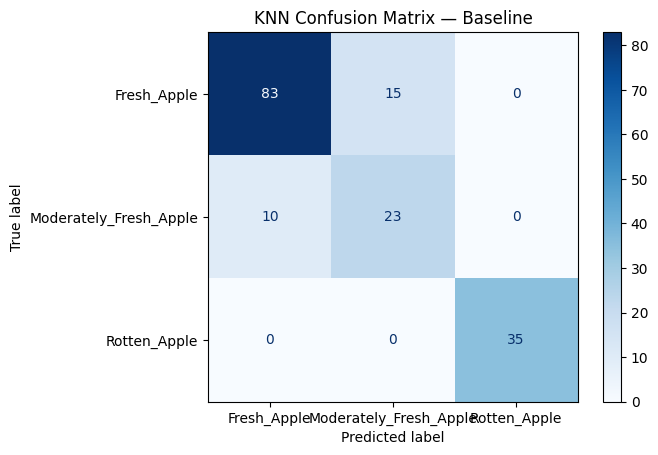

In [17]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Baseline')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Baseline')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Baseline')

## Ringkasan Hasil Baseline

Cell ini menampilkan ringkasan hasil klasifikasi pada percobaan baseline yang hanya menggunakan citra grayscale tanpa menerapkan preprocessing tambahan seperti filtering, histogram equalization, edge detection, maupun sharpening. Tujuan ringkasan ini adalah memberikan gambaran umum mengenai performa sistem sebelum dilakukan berbagai teknik preprocessing pada percobaan berikutnya.

Berdasarkan hasil feature selection, jumlah fitur berhasil direduksi dari 28 fitur GLCM menjadi 6 fitur terpilih yang dianggap paling relevan dan memiliki tingkat redundansi yang rendah. Pengurangan jumlah fitur ini membantu mengurangi kompleksitas data sekaligus mempertahankan informasi tekstur yang paling penting untuk proses klasifikasi.

Hasil pengujian menunjukkan bahwa Random Forest memperoleh performa terbaik dengan akurasi testing sebesar 90.96%, diikuti oleh SVM sebesar 86.14%, dan KNN sebesar 84.94%. Perbedaan performa ini menunjukkan bahwa setiap algoritma memiliki kemampuan yang berbeda dalam mempelajari pola hubungan antar fitur tekstur. Random Forest mampu memberikan hasil terbaik karena dapat menangani hubungan yang kompleks dan non-linear antar fitur melalui kombinasi banyak decision tree, sedangkan SVM dan KNN menunjukkan performa yang sedikit lebih rendah pada dataset ini.

Meskipun hanya menggunakan citra grayscale tanpa preprocessing tambahan, seluruh model berhasil mencapai akurasi di atas 84%, yang menunjukkan bahwa fitur tekstur GLCM mampu merepresentasikan karakteristik kesegaran apel dengan cukup baik. Selain itu, hasil confusion matrix sebelumnya menunjukkan bahwa seluruh model dapat mengenali kelas Rotten Apple secara sempurna, sementara sebagian besar kesalahan klasifikasi terjadi antara kelas Fresh Apple dan Moderately Fresh Apple yang memiliki karakteristik tekstur lebih mirip satu sama lain.

Hasil baseline ini akan digunakan sebagai acuan utama untuk mengevaluasi efektivitas metode preprocessing pada percobaan berikutnya. Apabila akurasi yang diperoleh setelah preprocessing lebih tinggi dibandingkan baseline, maka dapat disimpulkan bahwa preprocessing berhasil meningkatkan kualitas representasi tekstur citra. Sebaliknya, apabila performa tidak meningkat atau justru menurun, maka preprocessing yang digunakan kemungkinan tidak memberikan informasi tambahan yang signifikan atau bahkan menghilangkan karakteristik penting yang terdapat pada citra asli.

In [18]:
print('=== RINGKASAN HASIL BASELINE (GRAYSCALE SAJA) ===')
print(f'Preprocessing: Tidak ada (hanya Grayscale)')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL BASELINE (GRAYSCALE SAJA) ===
Preprocessing: Tidak ada (hanya Grayscale)
Jumlah Fitur Setelah Seleksi: 6

Akurasi Testing Set:
  Random Forest : 0.9096
  SVM           : 0.8614
  KNN           : 0.8494
